# 09b — Pharmacophore Consolidation and Screening-Ready Model

## PEARL Pipeline 5

`09a` extracted an MD-derived consensus pharmacophore from the production trajectories of:

```text
CF02
CF06
MPNN_NEW_05
```

The production 09a run produced 17 core consensus features from 300 sampled MD frames.
Several features are spatially co-localized or chemically overlapping, so the raw 17-feature
model should **not** be used as 17 simultaneous hard constraints.

### Goal of 09b

Transform the 09a production output into a **compact, screening-ready pharmacophore** by:

1. loading the authoritative 09a production tables;
2. validating the 17-feature core;
3. detecting spatially redundant feature points;
4. representing co-localized chemistry as **alternative/composite feature groups**;
5. assigning **mandatory**, **optional**, and **context** roles;
6. deriving spatial tolerances from the MD dispersion recorded in 09a;
7. exporting a compact CSV/JSON/PyMOL model;
8. running QC and generating a reproducible report.

The output remains a computational hypothesis for downstream molecular generation/screening.
It is not experimental proof of affinity or inhibition.


## 1. Consolidation principles

The reduction is intentionally rule-based and transparent.

### Evidence hierarchy

A feature/group is considered strongest when it has:

- support from all three peptide candidates;
- high mean MD occupancy;
- limited spatial dispersion;
- non-redundant chemical information.

### Redundancy treatment

Features closer than a configurable 3D distance are grouped when their pharmacophore
families are chemically compatible or clearly represent the same local region.

Examples expected from 09a include:

```text
HYD + ARO
HBD + HBA
HBD + POS
HBA + NEG
```

These are not interpreted as two mandatory atoms at the same position. Instead they become
a **composite/alternative pharmacophore group**.

### Role assignment

Default logic:

```text
MANDATORY
    support = 3
    group occupancy >= 0.75

OPTIONAL
    support >= 2
    group occupancy >= 0.75

CONTEXT
    remaining retained 09a core groups
```

A later screening step may require all mandatory groups plus a configurable number of
optional groups.


In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("09b environment loaded.")


09b environment loaded.


## 2. Configuration


In [2]:
# ======================================================
# Input: finalized 09a production output
# ======================================================

OUTPUTS_ROOT = Path("outputs")

INPUT_ROOT_09A = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09a_md_derived"
    / "production"
)

INPUT_TABLE_DIR_09A = (
    INPUT_ROOT_09A
    / "tables"
)

CORE_09A_PATH = (
    INPUT_TABLE_DIR_09A
    / "09a_core_consensus_pharmacophore.csv"
)

ALL_CONSENSUS_09A_PATH = (
    INPUT_TABLE_DIR_09A
    / "09a_consensus_pharmacophore_all.csv"
)

PERSISTENT_09A_PATH = (
    INPUT_TABLE_DIR_09A
    / "09a_candidate_persistent_features.csv"
)

QC_09A_PATH = (
    INPUT_TABLE_DIR_09A
    / "09a_QC.csv"
)

# ======================================================
# 09b consolidation parameters
# ======================================================

# Spatial threshold for identifying co-localized feature points.
REDUNDANCY_RADIUS_A = 1.25

# Evidence thresholds.
MANDATORY_MIN_SUPPORT = 3
MANDATORY_MIN_OCCUPANCY = 0.75

OPTIONAL_MIN_SUPPORT = 2
OPTIONAL_MIN_OCCUPANCY = 0.75

# Dynamic tolerance bounds.
MIN_TOLERANCE_A = 1.0
MAX_TOLERANCE_A = 3.0
DEFAULT_TOLERANCE_A = 1.5

# Screening rule:
# all mandatory groups + at least this many optional groups.
MIN_OPTIONAL_MATCHES = 1

# ======================================================
# Output
# ======================================================

OUTPUT_ROOT = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09b_consolidated"
)

TABLE_DIR = OUTPUT_ROOT / "tables"
MODEL_DIR = OUTPUT_ROOT / "models"
PLOT_DIR = OUTPUT_ROOT / "plots"
STRUCTURE_DIR = OUTPUT_ROOT / "structures"
REPORT_DIR = OUTPUT_ROOT / "reports"

for d in [
    TABLE_DIR,
    MODEL_DIR,
    PLOT_DIR,
    STRUCTURE_DIR,
    REPORT_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True,
    )

print("09a input:", CORE_09A_PATH)
print("09b output:", OUTPUT_ROOT)


09a input: outputs/pipeline_5_pharmacophore_09a_md_derived/production/tables/09a_core_consensus_pharmacophore.csv
09b output: outputs/pipeline_5_pharmacophore_09b_consolidated


## 3. Load and validate 09a production outputs


In [3]:
required_paths = [
    CORE_09A_PATH,
    ALL_CONSENSUS_09A_PATH,
    PERSISTENT_09A_PATH,
    QC_09A_PATH,
]

missing = [
    p
    for p in required_paths
    if not p.exists()
]

if missing:
    raise FileNotFoundError(
        "Missing required 09a production outputs:\n"
        + "\n".join(
            str(p)
            for p in missing
        )
    )

core09a = pd.read_csv(
    CORE_09A_PATH
)

all09a = pd.read_csv(
    ALL_CONSENSUS_09A_PATH
)

persistent09a = pd.read_csv(
    PERSISTENT_09A_PATH
)

qc09a = pd.read_csv(
    QC_09A_PATH
)

print(
    "09a core features:",
    len(core09a),
)

display(
    core09a
)

if len(core09a) != 17:
    raise RuntimeError(
        "Expected the finalized 09a production core to contain 17 features, "
        f"but found {len(core09a)}. Inspect the input before continuing."
    )

if "pass" in qc09a.columns:
    normalized_pass = (
        qc09a["pass"]
        .astype(str)
        .str.lower()
        .map({
            "true": True,
            "false": False,
        })
    )

    if normalized_pass.isna().any():
        normalized_pass = qc09a["pass"].astype(bool)

    if not bool(
        normalized_pass.all()
    ):
        raise RuntimeError(
            "09a production QC did not pass completely."
        )

print(
    "09a production input validation: PASS"
)


09a core features: 17


,cluster_id,feature_type,x_A,y_A,z_A,n_candidate_features,n_candidate_support,candidate_support,mean_member_occupancy,max_member_occupancy,max_member_distance_to_centroid_A,member_labels
0,PH001,HBD,49.729014,30.637344,45.599409,3,3,"CF02,CF06,MPNN_NEW_05",1.000000,1.00,1.384000,CF02:ARG4:HBD; CF06:ARG4:HBD; MPNN_NEW_05:ARG4...
1,PH015,HYD,49.179592,41.926508,55.570514,3,3,"CF02,CF06,MPNN_NEW_05",1.000000,1.00,1.729471,CF02:ILE1:HYD; CF06:ILE1:HYD; MPNN_NEW_05:ILE1...
2,PH016,HYD,53.910534,36.722378,54.232110,3,3,"CF02,CF06,MPNN_NEW_05",1.000000,1.00,2.015119,CF02:TYR7:HYD; CF06:TYR7:HYD; MPNN_NEW_05:TYR7...
3,PH022,ARO,53.910534,36.722378,54.232110,3,3,"CF02,CF06,MPNN_NEW_05",1.000000,1.00,2.015119,CF02:TYR7:ARO; CF06:TYR7:ARO; MPNN_NEW_05:TYR7...
4,PH024,POS,49.860300,30.235134,45.531713,3,3,"CF02,CF06,MPNN_NEW_05",1.000000,1.00,1.380051,CF02:ARG4:POS; CF06:ARG4:POS; MPNN_NEW_05:ARG4...
5,PH002,HBD,56.047425,35.913194,52.677189,3,3,"CF02,CF06,MPNN_NEW_05",0.823333,1.00,2.225775,MPNN_NEW_05:TYR7:HBD; CF02:TYR7:HBD; CF06:TYR7...
6,PH011,HBA,56.047425,35.913194,52.677189,3,3,"CF02,CF06,MPNN_NEW_05",0.823333,1.00,2.225775,MPNN_NEW_05:TYR7:HBA; CF02:TYR7:HBA; CF06:TYR7...
7,PH006,HBD,52.346881,36.474574,50.085317,3,3,"CF02,CF06,MPNN_NEW_05",0.780000,0.98,1.404839,CF06:GLN6:HBD; MPNN_NEW_05:GLN6:HBD; CF02:GLN6...
8,PH003,HBD,43.830996,37.136786,50.788071,3,3,"CF02,CF06,MPNN_NEW_05",0.733333,1.00,1.360146,MPNN_NEW_05:HIS5:HBD; CF02:SER5:HBD; CF06:CYS5...
9,PH010,HBA,43.830996,37.136786,50.788071,3,3,"CF02,CF06,MPNN_NEW_05",0.733333,1.00,1.360146,MPNN_NEW_05:HIS5:HBA; CF02:SER5:HBA; CF06:CYS5...


09a production input validation: PASS


## 4. Feature-family compatibility for consolidation

Only nearby features with compatible meanings are merged into one screening group.

The compatibility map is conservative:

```text
same family          -> merge
HYD / ARO            -> merge as hydrophobic/aromatic alternatives
HBD / HBA            -> merge as polar donor/acceptor alternatives
HBD / POS            -> merge as donor/positive alternatives
HBA / NEG            -> merge as acceptor/negative alternatives
```

Other close pairs remain separate.


In [4]:
COMPATIBLE_PAIRS = {
    frozenset(["HYD", "ARO"]),
    frozenset(["HBD", "HBA"]),
    frozenset(["HBD", "POS"]),
    frozenset(["HBA", "NEG"]),
}

def families_compatible(a, b):
    if a == b:
        return True

    return (
        frozenset([a, b])
        in COMPATIBLE_PAIRS
    )


## 5. Detect spatially redundant 09a features


In [5]:
coords = core09a[
    ["x_A", "y_A", "z_A"]
].to_numpy(
    dtype=float
)

pair_rows = []

for i in range(
    len(core09a)
):
    for j in range(
        i + 1,
        len(core09a),
    ):
        d = float(
            np.linalg.norm(
                coords[i]
                - coords[j]
            )
        )

        fi = core09a.iloc[i]
        fj = core09a.iloc[j]

        compatible = families_compatible(
            fi["feature_type"],
            fj["feature_type"],
        )

        pair_rows.append({
            "feature_1": fi["cluster_id"],
            "type_1": fi["feature_type"],
            "feature_2": fj["cluster_id"],
            "type_2": fj["feature_type"],
            "distance_A": d,
            "within_redundancy_radius": (
                d <= REDUNDANCY_RADIUS_A
            ),
            "chemically_compatible": compatible,
            "merge_candidate": (
                d <= REDUNDANCY_RADIUS_A
                and compatible
            ),
        })

pair_df = pd.DataFrame(
    pair_rows
).sort_values(
    "distance_A"
)

display(
    pair_df.head(30)
)

pair_df.to_csv(
    TABLE_DIR
    / "09b_pairwise_feature_distances.csv",
    index=False,
)

print(
    "Merge-candidate pairs:",
    int(
        pair_df[
            "merge_candidate"
        ].sum()
    ),
)


,feature_1,type_1,feature_2,type_2,distance_A,within_redundancy_radius,chemically_compatible,merge_candidate
100,PH003,HBD,PH010,HBA,0.000000,True,True,True
70,PH002,HBD,PH011,HBA,0.000000,True,True,True
31,PH016,HYD,PH022,ARO,0.000000,True,True,True
127,PH012,HBA,PH031,NEG,0.186193,True,True,True
122,PH004,HBD,PH025,POS,0.229197,True,True,True
135,PH005,HBD,PH027,POS,0.359204,True,True,True
3,PH001,HBD,PH024,POS,0.428476,True,True,True
34,PH016,HYD,PH011,HBA,2.763849,False,False,False
46,PH022,ARO,PH002,HBD,2.763849,False,False,False
47,PH022,ARO,PH011,HBA,2.763849,False,False,False


Merge-candidate pairs: 7


## 6. Build redundancy-connected components

The graph is deterministic: each 09a feature is a node, and an edge is created only for a
spatially close, chemically compatible pair.

Connected components become consolidated screening groups.


In [6]:
feature_ids = core09a[
    "cluster_id"
].tolist()

parent = {
    x: x
    for x in feature_ids
}

def find(x):
    while parent[x] != x:
        parent[x] = parent[
            parent[x]
        ]
        x = parent[x]

    return x

def union(a, b):
    ra = find(a)
    rb = find(b)

    if ra != rb:
        parent[rb] = ra

for row in pair_df.itertuples():
    if row.merge_candidate:
        union(
            row.feature_1,
            row.feature_2,
        )

components = {}

for feature_id in feature_ids:
    root = find(
        feature_id
    )

    components.setdefault(
        root,
        [],
    ).append(
        feature_id
    )

component_list = list(
    components.values()
)

print(
    "09a raw core features:",
    len(core09a),
)

print(
    "Consolidated components:",
    len(component_list),
)

for i, component in enumerate(
    component_list,
    start=1,
):
    print(
        f"G{i:02d}:",
        component,
    )


09a raw core features: 17
Consolidated components: 10
G01: ['PH001', 'PH024']
G02: ['PH015']
G03: ['PH016', 'PH022']
G04: ['PH002', 'PH011']
G05: ['PH006']
G06: ['PH003', 'PH010']
G07: ['PH017']
G08: ['PH004', 'PH025']
G09: ['PH012', 'PH031']
G10: ['PH005', 'PH027']


## 7. Consolidate groups and derive screening tolerances

The group centroid is occupancy-weighted.

The tolerance radius combines:

- the spread of member centroids inside the consolidated group;
- the 09a member-cluster dispersion, when available;
- a minimum practical pharmacophore tolerance.

It is capped to avoid producing excessively permissive screening volumes.


In [7]:
def safe_numeric(
    series,
    default=np.nan,
):
    x = pd.to_numeric(
        series,
        errors="coerce",
    )

    if x.notna().any():
        return x

    return pd.Series(
        [default] * len(series),
        index=series.index,
    )


group_rows = []
membership_rows = []

for group_index, member_ids in enumerate(
    component_list,
    start=1,
):
    group_id = f"PG{group_index:02d}"

    sub = core09a[
        core09a[
            "cluster_id"
        ].isin(
            member_ids
        )
    ].copy()

    weights = (
        safe_numeric(
            sub[
                "mean_member_occupancy"
            ],
            default=1.0,
        )
        .fillna(
            1.0
        )
        .to_numpy(
            dtype=float
        )
    )

    xyz = sub[
        ["x_A", "y_A", "z_A"]
    ].to_numpy(
        dtype=float
    )

    centroid = np.average(
        xyz,
        axis=0,
        weights=weights,
    )

    member_offsets = np.linalg.norm(
        xyz - centroid,
        axis=1,
    )

    local_spread = float(
        member_offsets.max()
    ) if len(member_offsets) else 0.0

    if (
        "max_member_distance_to_centroid_A"
        in sub.columns
    ):
        source_dispersion = float(
            safe_numeric(
                sub[
                    "max_member_distance_to_centroid_A"
                ],
                default=0.0,
            )
            .fillna(
                0.0
            )
            .max()
        )
    else:
        source_dispersion = 0.0

    raw_tolerance = max(
        DEFAULT_TOLERANCE_A,
        local_spread
        + source_dispersion,
    )

    tolerance_A = float(
        np.clip(
            raw_tolerance,
            MIN_TOLERANCE_A,
            MAX_TOLERANCE_A,
        )
    )

    families = sorted(
        sub[
            "feature_type"
        ].astype(str).unique()
    )

    supports = safe_numeric(
        sub[
            "n_candidate_support"
        ],
        default=0,
    ).fillna(
        0
    )

    occupancy = safe_numeric(
        sub[
            "mean_member_occupancy"
        ],
        default=0.0,
    ).fillna(
        0.0
    )

    group_support = int(
        supports.max()
    )

    group_occupancy = float(
        np.average(
            occupancy.to_numpy(
                dtype=float
            ),
            weights=weights,
        )
    )

    candidate_sets = []

    for value in sub[
        "candidate_support"
    ].astype(str):
        candidate_sets.append(
            set(
                x.strip()
                for x in value.split(",")
                if x.strip()
            )
        )

    candidate_union = sorted(
        set().union(
            *candidate_sets
        )
    )

    if (
        group_support
        >= MANDATORY_MIN_SUPPORT
        and group_occupancy
        >= MANDATORY_MIN_OCCUPANCY
    ):
        role = "MANDATORY"

    elif (
        group_support
        >= OPTIONAL_MIN_SUPPORT
        and group_occupancy
        >= OPTIONAL_MIN_OCCUPANCY
    ):
        role = "OPTIONAL"

    else:
        role = "CONTEXT"

    if len(
        families
    ) == 1:
        chemistry_mode = (
            families[0]
        )
    else:
        chemistry_mode = (
            "ANY_OF("
            + ",".join(
                families
            )
            + ")"
        )

    group_rows.append({
        "group_id": group_id,
        "role": role,
        "chemistry_mode": chemistry_mode,
        "feature_families": ",".join(
            families
        ),
        "n_source_features": len(
            sub
        ),
        "source_cluster_ids": ",".join(
            sub[
                "cluster_id"
            ].astype(str)
        ),
        "candidate_support_count": len(
            candidate_union
        ),
        "candidate_support": ",".join(
            candidate_union
        ),
        "evidence_support_max": group_support,
        "mean_occupancy": group_occupancy,
        "x_A": float(
            centroid[0]
        ),
        "y_A": float(
            centroid[1]
        ),
        "z_A": float(
            centroid[2]
        ),
        "tolerance_A": tolerance_A,
        "member_centroid_spread_A": local_spread,
        "source_dispersion_A": source_dispersion,
    })

    for source_row in sub.itertuples():
        membership_rows.append({
            "group_id": group_id,
            "source_cluster_id": source_row.cluster_id,
            "source_feature_type": source_row.feature_type,
            "source_support": source_row.n_candidate_support,
            "source_occupancy": source_row.mean_member_occupancy,
        })

consolidated_df = pd.DataFrame(
    group_rows
)

membership_df = pd.DataFrame(
    membership_rows
)

role_order = pd.CategoricalDtype(
    [
        "MANDATORY",
        "OPTIONAL",
        "CONTEXT",
    ],
    ordered=True,
)

consolidated_df[
    "role"
] = consolidated_df[
    "role"
].astype(
    role_order
)

consolidated_df = consolidated_df.sort_values(
    [
        "role",
        "candidate_support_count",
        "mean_occupancy",
    ],
    ascending=[
        True,
        False,
        False,
    ],
).reset_index(
    drop=True
)

display(
    consolidated_df
)

consolidated_df.to_csv(
    TABLE_DIR
    / "09b_consolidated_pharmacophore_groups.csv",
    index=False,
)

membership_df.to_csv(
    TABLE_DIR
    / "09b_group_membership.csv",
    index=False,
)


,group_id,role,chemistry_mode,feature_families,n_source_features,source_cluster_ids,candidate_support_count,candidate_support,evidence_support_max,mean_occupancy,x_A,y_A,z_A,tolerance_A,member_centroid_spread_A,source_dispersion_A
0,PG01,MANDATORY,"ANY_OF(HBD,POS)","HBD,POS",2,"PH001,PH024",3,"CF02,CF06,MPNN_NEW_05",3,1.000000,49.794657,30.436239,45.565561,1.598238,2.142382e-01,1.384000
1,PG02,MANDATORY,HYD,HYD,1,PH015,3,"CF02,CF06,MPNN_NEW_05",3,1.000000,49.179592,41.926508,55.570514,1.729471,0.000000e+00,1.729471
2,PG03,MANDATORY,"ANY_OF(ARO,HYD)","ARO,HYD",2,"PH016,PH022",3,"CF02,CF06,MPNN_NEW_05",3,1.000000,53.910534,36.722378,54.232110,2.015119,0.000000e+00,2.015119
3,PG04,MANDATORY,"ANY_OF(HBA,HBD)","HBA,HBD",2,"PH002,PH011",3,"CF02,CF06,MPNN_NEW_05",3,0.823333,56.047425,35.913194,52.677189,2.225775,0.000000e+00,2.225775
4,PG05,MANDATORY,HBD,HBD,1,PH006,3,"CF02,CF06,MPNN_NEW_05",3,0.780000,52.346881,36.474574,50.085317,1.500000,7.105427e-15,1.404839
5,PG07,OPTIONAL,HYD,HYD,1,PH017,2,"CF02,MPNN_NEW_05",2,1.000000,52.069077,36.610771,62.514597,1.500000,0.000000e+00,0.905159
6,PG08,OPTIONAL,"ANY_OF(HBD,POS)","HBD,POS",2,"PH004,PH025",2,"CF02,CF06",2,0.940000,52.004954,47.789542,63.628426,1.500000,1.145984e-01,0.983544
7,PG09,OPTIONAL,"ANY_OF(HBA,NEG)","HBA,NEG",2,"PH012,PH031",2,"CF02,CF06",2,0.940000,50.256623,39.361287,43.817816,1.596598,9.309673e-02,1.503502
8,PG10,OPTIONAL,"ANY_OF(HBD,POS)","HBD,POS",2,"PH005,PH027",2,"CF02,CF06",2,0.836078,45.323375,33.203490,60.033630,1.574702,1.860549e-01,1.388647
9,PG06,CONTEXT,"ANY_OF(HBA,HBD)","HBA,HBD",2,"PH003,PH010",3,"CF02,CF06,MPNN_NEW_05",3,0.733333,43.830996,37.136786,50.788071,1.500000,0.000000e+00,1.360146


## 8. Build the compact screening model


In [8]:
screening_df = consolidated_df[
    consolidated_df[
        "role"
    ].isin(
        [
            "MANDATORY",
            "OPTIONAL",
        ]
    )
].copy()

mandatory_df = screening_df[
    screening_df[
        "role"
    ]
    == "MANDATORY"
].copy()

optional_df = screening_df[
    screening_df[
        "role"
    ]
    == "OPTIONAL"
].copy()

print(
    "Mandatory groups:",
    len(
        mandatory_df
    ),
)

print(
    "Optional groups:",
    len(
        optional_df
    ),
)

print(
    "Context-only groups:",
    int(
        (
            consolidated_df[
                "role"
            ]
            == "CONTEXT"
        ).sum()
    ),
)

display(
    screening_df
)

if len(
    mandatory_df
) == 0:
    raise RuntimeError(
        "No mandatory pharmacophore groups were produced. "
        "Thresholds require review."
    )

screening_df.to_csv(
    TABLE_DIR
    / "09b_screening_ready_pharmacophore.csv",
    index=False,
)


Mandatory groups: 5
Optional groups: 4
Context-only groups: 1


,group_id,role,chemistry_mode,feature_families,n_source_features,source_cluster_ids,candidate_support_count,candidate_support,evidence_support_max,mean_occupancy,x_A,y_A,z_A,tolerance_A,member_centroid_spread_A,source_dispersion_A
0,PG01,MANDATORY,"ANY_OF(HBD,POS)","HBD,POS",2,"PH001,PH024",3,"CF02,CF06,MPNN_NEW_05",3,1.000000,49.794657,30.436239,45.565561,1.598238,2.142382e-01,1.384000
1,PG02,MANDATORY,HYD,HYD,1,PH015,3,"CF02,CF06,MPNN_NEW_05",3,1.000000,49.179592,41.926508,55.570514,1.729471,0.000000e+00,1.729471
2,PG03,MANDATORY,"ANY_OF(ARO,HYD)","ARO,HYD",2,"PH016,PH022",3,"CF02,CF06,MPNN_NEW_05",3,1.000000,53.910534,36.722378,54.232110,2.015119,0.000000e+00,2.015119
3,PG04,MANDATORY,"ANY_OF(HBA,HBD)","HBA,HBD",2,"PH002,PH011",3,"CF02,CF06,MPNN_NEW_05",3,0.823333,56.047425,35.913194,52.677189,2.225775,0.000000e+00,2.225775
4,PG05,MANDATORY,HBD,HBD,1,PH006,3,"CF02,CF06,MPNN_NEW_05",3,0.780000,52.346881,36.474574,50.085317,1.500000,7.105427e-15,1.404839
5,PG07,OPTIONAL,HYD,HYD,1,PH017,2,"CF02,MPNN_NEW_05",2,1.000000,52.069077,36.610771,62.514597,1.500000,0.000000e+00,0.905159
6,PG08,OPTIONAL,"ANY_OF(HBD,POS)","HBD,POS",2,"PH004,PH025",2,"CF02,CF06",2,0.940000,52.004954,47.789542,63.628426,1.500000,1.145984e-01,0.983544
7,PG09,OPTIONAL,"ANY_OF(HBA,NEG)","HBA,NEG",2,"PH012,PH031",2,"CF02,CF06",2,0.940000,50.256623,39.361287,43.817816,1.596598,9.309673e-02,1.503502
8,PG10,OPTIONAL,"ANY_OF(HBD,POS)","HBD,POS",2,"PH005,PH027",2,"CF02,CF06",2,0.836078,45.323375,33.203490,60.033630,1.574702,1.860549e-01,1.388647


## 9. Screening rule

The exported model uses a transparent two-tier matching rule:

```text
REQUIRE:
    every MANDATORY group

AND:
    at least MIN_OPTIONAL_MATCHES OPTIONAL groups
```

For a composite group such as `ANY_OF(HYD,ARO)`, either listed family may satisfy the
same spatial region.

This prevents co-localized features from being counted as independent mandatory constraints.


In [9]:
screening_rule = {
    "mandatory_match_rule": "ALL",
    "optional_match_rule": "AT_LEAST_N",
    "min_optional_matches": int(
        min(
            MIN_OPTIONAL_MATCHES,
            len(
                optional_df
            ),
        )
    ),
    "composite_group_rule": (
        "ANY listed feature family may satisfy the group"
    ),
    "distance_rule": (
        "candidate feature center must lie within group tolerance_A"
    ),
}

display(
    pd.DataFrame(
        [
            screening_rule
        ]
    )
)


,mandatory_match_rule,optional_match_rule,min_optional_matches,composite_group_rule,distance_rule
0,ALL,AT_LEAST_N,1,ANY listed feature family may satisfy the group,candidate feature center must lie within group...


## 10. Export screening-ready JSON


In [10]:
def clean_record(
    record
):
    cleaned = {}

    for key, value in record.items():
        if isinstance(
            value,
            (
                np.integer,
            ),
        ):
            value = int(
                value
            )

        elif isinstance(
            value,
            (
                np.floating,
            ),
        ):
            value = float(
                value
            )

        if pd.isna(
            value
        ):
            value = None

        cleaned[
            key
        ] = value

    return cleaned


model_payload = {
    "model_name": (
        "PEARL_09b_MD_derived_screening_pharmacophore"
    ),
    "source": {
        "pipeline": "PEARL Pipeline 5",
        "source_notebook": "09a MD-derived pharmacophore production",
        "source_candidates": [
            "CF02",
            "CF06",
            "MPNN_NEW_05",
        ],
        "raw_core_feature_count": int(
            len(
                core09a
            )
        ),
    },
    "consolidation": {
        "redundancy_radius_A": REDUNDANCY_RADIUS_A,
        "mandatory_min_support": MANDATORY_MIN_SUPPORT,
        "mandatory_min_occupancy": MANDATORY_MIN_OCCUPANCY,
        "optional_min_support": OPTIONAL_MIN_SUPPORT,
        "optional_min_occupancy": OPTIONAL_MIN_OCCUPANCY,
    },
    "screening_rule": screening_rule,
    "groups": [
        clean_record(
            record
        )
        for record in screening_df.astype(
            object
        ).to_dict(
            orient="records"
        )
    ],
    "limitations": [
        (
            "MD-derived computational pharmacophore; "
            "not experimental binding evidence."
        ),
        (
            "Tolerances are derived from the short production "
            "MD ensembles and consolidation rules."
        ),
        (
            "Downstream hits require chemical filtering, "
            "docking and energetic/structural validation."
        ),
    ],
}

json_path = (
    MODEL_DIR
    / "09b_screening_ready_pharmacophore.json"
)

json_path.write_text(
    json.dumps(
        model_payload,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "JSON model:",
    json_path,
)


JSON model: outputs/pipeline_5_pharmacophore_09b_consolidated/models/09b_screening_ready_pharmacophore.json


## 11. Export PyMOL visualization


In [11]:
PYMOL_COLORS = {
    "HBD": "blue",
    "HBA": "red",
    "HYD": "orange",
    "ARO": "purple",
    "POS": "marine",
    "NEG": "firebrick",
}

pml_lines = [
    "# PEARL 09b consolidated screening pharmacophore",
    "delete PEARL09B_*",
]

for row in screening_df.itertuples():
    families = str(
        row.feature_families
    ).split(
        ","
    )

    primary_family = families[0]

    color = PYMOL_COLORS.get(
        primary_family,
        "gray",
    )

    object_name = (
        f"PEARL09B_{row.group_id}"
    )

    label = (
        f"{row.group_id}:{row.role}:"
        f"{row.chemistry_mode}:r={row.tolerance_A:.2f}"
    )

    pml_lines.append(
        "pseudoatom "
        f"{object_name}, "
        f"pos=[{row.x_A:.3f},{row.y_A:.3f},{row.z_A:.3f}], "
        f"label='{label}'"
    )

    pml_lines.append(
        f"color {color}, {object_name}"
    )

    pml_lines.append(
        f"show spheres, {object_name}"
    )

    pml_lines.append(
        f"set sphere_scale, {max(0.35, row.tolerance_A / 3.0):.3f}, {object_name}"
    )

pml_path = (
    STRUCTURE_DIR
    / "09b_screening_ready_pharmacophore.pml"
)

pml_path.write_text(
    "\n".join(
        pml_lines
    ),
    encoding="utf-8",
)

print(
    "PyMOL script:",
    pml_path,
)


PyMOL script: outputs/pipeline_5_pharmacophore_09b_consolidated/structures/09b_screening_ready_pharmacophore.pml


## 12. Pairwise distance matrix between screening groups


In [12]:
group_ids = screening_df[
    "group_id"
].tolist()

group_xyz = screening_df[
    ["x_A", "y_A", "z_A"]
].to_numpy(
    dtype=float
)

distance_matrix = np.zeros(
    (
        len(
            screening_df
        ),
        len(
            screening_df
        ),
    ),
    dtype=float,
)

for i in range(
    len(
        screening_df
    )
):
    for j in range(
        len(
            screening_df
        )
    ):
        distance_matrix[
            i,
            j,
        ] = np.linalg.norm(
            group_xyz[i]
            - group_xyz[j]
        )

distance_df = pd.DataFrame(
    distance_matrix,
    index=group_ids,
    columns=group_ids,
)

display(
    distance_df.round(
        2
    )
)

distance_df.to_csv(
    TABLE_DIR
    / "09b_screening_group_distance_matrix_A.csv"
)


,PG01,PG02,PG03,PG04,PG05,PG07,PG08,PG09,PG10
PG01,0.00,15.25,11.47,10.94,7.96,18.18,25.15,9.11,15.39
PG02,15.25,0.00,7.16,9.58,8.36,9.21,10.36,12.08,10.53
PG03,11.47,7.16,0.00,2.76,4.44,8.49,14.64,11.35,10.94
PG04,10.94,9.58,2.76,0.00,4.55,10.63,16.65,11.13,13.28
PG05,7.96,8.36,4.44,4.55,0.00,12.43,17.65,7.21,12.61
PG07,18.18,9.21,8.49,10.63,12.43,0.00,11.23,18.98,7.95
PG08,25.15,10.36,14.64,16.65,17.65,11.23,0.00,21.60,16.44
PG09,9.11,12.08,11.35,11.13,7.21,18.98,21.60,0.00,18.03
PG10,15.39,10.53,10.94,13.28,12.61,7.95,16.44,18.03,0.00


## 13. Diagnostic plots


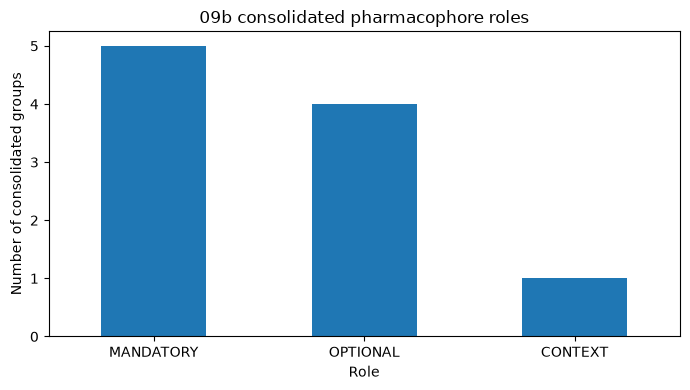

Saved: outputs/pipeline_5_pharmacophore_09b_consolidated/plots/09b_role_counts.png


In [13]:
role_counts = (
    consolidated_df[
        "role"
    ]
    .astype(str)
    .value_counts()
    .reindex(
        [
            "MANDATORY",
            "OPTIONAL",
            "CONTEXT",
        ],
        fill_value=0,
    )
)

ax = role_counts.plot(
    kind="bar",
    figsize=(7, 4),
)

ax.set_ylabel(
    "Number of consolidated groups"
)

ax.set_xlabel(
    "Role"
)

ax.set_title(
    "09b consolidated pharmacophore roles"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

path = (
    PLOT_DIR
    / "09b_role_counts.png"
)

plt.savefig(
    path,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)


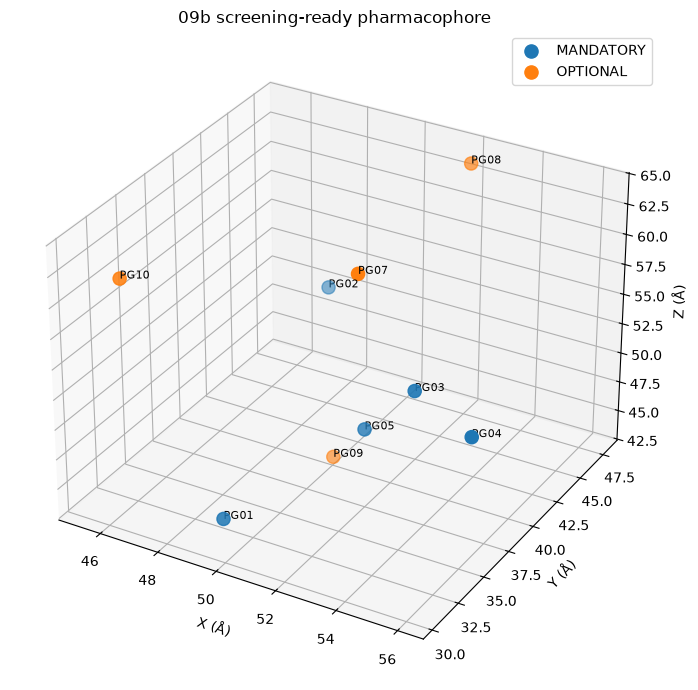

Saved: outputs/pipeline_5_pharmacophore_09b_consolidated/plots/09b_screening_ready_pharmacophore_3D.png


In [14]:
fig = plt.figure(
    figsize=(9, 7)
)

ax = fig.add_subplot(
    111,
    projection="3d",
)

for role in [
    "MANDATORY",
    "OPTIONAL",
]:
    sub = screening_df[
        screening_df[
            "role"
        ]
        == role
    ]

    if sub.empty:
        continue

    ax.scatter(
        sub[
            "x_A"
        ],
        sub[
            "y_A"
        ],
        sub[
            "z_A"
        ],
        s=90,
        label=role,
    )

    for row in sub.itertuples():
        ax.text(
            row.x_A,
            row.y_A,
            row.z_A,
            row.group_id,
            fontsize=8,
        )

ax.set_xlabel(
    "X (Å)"
)

ax.set_ylabel(
    "Y (Å)"
)

ax.set_zlabel(
    "Z (Å)"
)

ax.set_title(
    "09b screening-ready pharmacophore"
)

ax.legend()

plt.tight_layout()

path = (
    PLOT_DIR
    / "09b_screening_ready_pharmacophore_3D.png"
)

plt.savefig(
    path,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)


## 14. Quality control

09b QC checks that:

- finalized 09a production QC passed;
- all 17 raw core features were assigned exactly once;
- no source feature was lost or duplicated;
- consolidated groups are fewer than raw features;
- at least one mandatory screening group exists;
- all screening tolerances lie inside the configured range;
- JSON and PyMOL exports were created.


In [15]:
assigned_source_ids = membership_df[
    "source_cluster_id"
].tolist()

unique_assigned = set(
    assigned_source_ids
)

raw_ids = set(
    core09a[
        "cluster_id"
    ].astype(str)
)

qc_rows = [
    {
        "check": "09a_core_count_is_17",
        "pass": (
            len(
                core09a
            )
            == 17
        ),
    },
    {
        "check": "all_09a_features_assigned",
        "pass": (
            unique_assigned
            == raw_ids
        ),
    },
    {
        "check": "no_feature_assigned_twice",
        "pass": (
            len(
                assigned_source_ids
            )
            == len(
                unique_assigned
            )
        ),
    },
    {
        "check": "consolidation_reduces_or_preserves_count",
        "pass": (
            len(
                consolidated_df
            )
            <= len(
                core09a
            )
        ),
    },
    {
        "check": "mandatory_groups_nonempty",
        "pass": (
            len(
                mandatory_df
            )
            > 0
        ),
    },
    {
        "check": "screening_groups_nonempty",
        "pass": (
            len(
                screening_df
            )
            > 0
        ),
    },
    {
        "check": "tolerance_bounds_valid",
        "pass": bool(
            (
                screening_df[
                    "tolerance_A"
                ]
                .between(
                    MIN_TOLERANCE_A,
                    MAX_TOLERANCE_A,
                )
            ).all()
        ),
    },
    {
        "check": "screening_json_created",
        "pass": (
            json_path.exists()
        ),
    },
    {
        "check": "pymol_export_created",
        "pass": (
            pml_path.exists()
        ),
    },
]

qc_df = pd.DataFrame(
    qc_rows
)

ALL_QC_PASSED = bool(
    qc_df[
        "pass"
    ].all()
)

display(
    qc_df
)

print(
    "ALL QC PASSED:",
    ALL_QC_PASSED,
)

qc_df.to_csv(
    TABLE_DIR
    / "09b_QC.csv",
    index=False,
)


,check,pass
0,09a_core_count_is_17,True
1,all_09a_features_assigned,True
2,no_feature_assigned_twice,True
3,consolidation_reduces_or_preserves_count,True
4,mandatory_groups_nonempty,True
5,screening_groups_nonempty,True
6,tolerance_bounds_valid,True
7,screening_json_created,True
8,pymol_export_created,True


ALL QC PASSED: True


## 15. Automatic report


In [16]:
report_lines = [
    "# 09b — Pharmacophore Consolidation and Screening-Ready Model",
    "",
    "## Input",
    f"- 09a raw core features: {len(core09a)}",
    "- Source candidates: CF02, CF06, MPNN_NEW_05",
    "",
    "## Consolidation",
    f"- Redundancy radius: {REDUNDANCY_RADIUS_A:.2f} Å",
    f"- Consolidated groups: {len(consolidated_df)}",
    f"- Mandatory groups: {len(mandatory_df)}",
    f"- Optional groups: {len(optional_df)}",
    f"- Context groups: {(consolidated_df['role'].astype(str) == 'CONTEXT').sum()}",
    "",
    "## Screening rule",
    "- All mandatory groups must be matched.",
    (
        f"- At least {screening_rule['min_optional_matches']} "
        "optional group(s) must additionally be matched."
    ),
    "- Composite groups use ANY_OF feature-family logic.",
    "",
    "## Screening-ready groups",
]

for row in screening_df.itertuples():
    report_lines.append(
        (
            f"- {row.group_id} | {row.role} | "
            f"{row.chemistry_mode} | "
            f"support={row.candidate_support_count} "
            f"({row.candidate_support}) | "
            f"occupancy={row.mean_occupancy:.3f} | "
            f"xyz=({row.x_A:.2f}, {row.y_A:.2f}, {row.z_A:.2f}) Å | "
            f"tol={row.tolerance_A:.2f} Å | "
            f"source={row.source_cluster_ids}"
        )
    )

report_lines.extend([
    "",
    "## Interpretation",
    (
        "09b converts the raw 09a MD-derived pharmacophore into a compact "
        "two-tier screening model while preserving traceability to every "
        "source 09a feature."
    ),
    (
        "Co-localized pharmacophore families are represented as composite "
        "alternatives rather than independent hard constraints."
    ),
    (
        "Mandatory/optional status is evidence-based and depends on "
        "cross-candidate support plus MD occupancy, not on a single peptide "
        "or a single scoring method."
    ),
    (
        "This model is intended for downstream virtual screening or constrained "
        "generation. Hits must still undergo chemical filtering, docking and "
        "structural/energetic validation."
    ),
    "",
    f"ALL QC PASSED: {ALL_QC_PASSED}",
])

report_text = "\n".join(
    report_lines
)

report_path = (
    REPORT_DIR
    / "09b_pharmacophore_consolidation_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

print(
    report_text
)

print(
    "\nReport:",
    report_path.resolve(),
)


# 09b — Pharmacophore Consolidation and Screening-Ready Model

## Input
- 09a raw core features: 17
- Source candidates: CF02, CF06, MPNN_NEW_05

## Consolidation
- Redundancy radius: 1.25 Å
- Consolidated groups: 10
- Mandatory groups: 5
- Optional groups: 4
- Context groups: 1

## Screening rule
- All mandatory groups must be matched.
- At least 1 optional group(s) must additionally be matched.
- Composite groups use ANY_OF feature-family logic.

## Screening-ready groups
- PG01 | MANDATORY | ANY_OF(HBD,POS) | support=3 (CF02,CF06,MPNN_NEW_05) | occupancy=1.000 | xyz=(49.79, 30.44, 45.57) Å | tol=1.60 Å | source=PH001,PH024
- PG02 | MANDATORY | HYD | support=3 (CF02,CF06,MPNN_NEW_05) | occupancy=1.000 | xyz=(49.18, 41.93, 55.57) Å | tol=1.73 Å | source=PH015
- PG03 | MANDATORY | ANY_OF(ARO,HYD) | support=3 (CF02,CF06,MPNN_NEW_05) | occupancy=1.000 | xyz=(53.91, 36.72, 54.23) Å | tol=2.02 Å | source=PH016,PH022
- PG04 | MANDATORY | ANY_OF(HBA,HBD) | support=3 (CF02,CF06,MPNN_NEW_05) |

# 16. Final interpretation and next step

If `ALL QC PASSED: True`, 09b completes the pharmacophore-consolidation stage.

```text
09a
17 MD-derived core features
        ↓
09b
spatial/chemical redundancy handling
        ↓
MANDATORY + OPTIONAL screening groups
        ↓
screening-ready CSV + JSON + PyMOL model
```

The next stage should **not** modify the pharmacophore again unless 09b reveals an
unreasonable number of mandatory constraints.

The natural continuation is:

```text
09c — Pharmacophore-constrained molecular generation / candidate acquisition
```

09c should consume the 09b JSON/CSV model, generate or acquire chemically valid
small-molecule / peptidomimetic candidates, and preserve the pharmacophore match as an
explicit downstream selection criterion.
